# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap awal ini, mengimpor pustaka (*library*) Python yang krusial untuk melakukan inspeksi, pembersihan (*cleaning*), dan penyiapan (*preprocessing*) data teks ulasan Mobile Legends. Proses ini sangat penting agar data mentah siap digunakan untuk pemodelan *Machine Learning*.

### **Pustaka yang Digunakan:**
1. **Manipulasi & Analisis Data:** `pandas` dan `numpy` untuk membaca dataset dan mengolah struktur tabel.
2. **Visualisasi Data:** `matplotlib` dan `seaborn` untuk melihat distribusi rating atau jumlah ulasan.
3. **Pembersihan Teks (NLP):**
   * `re` (Regular Expression) untuk menghapus karakter khusus, angka, dan emoji.
   * `string` untuk manipulasi teks standar (menghapus tanda baca).
4. **Sastrawi (Pustaka Bahasa Indonesia):**
   * `StopWordRemoverFactory` untuk menghapus kata-kata yang tidak bermakna (seperti: "yang", "di", "dan").
   * `StemmerFactory` untuk mengubah kata berimbuhan menjadi kata dasar (misal: "mendownload" menjadi "download").

In [ ]:
# ==============================================================================
# 1. INSTALASI LIBRARY KHUSUS (BAHASA INDONESIA & KAGGLE)
# ==============================================================================
# Menginstall library Sastrawi untuk NLP Indonesia dan Kagglehub untuk unduh dataset
!pip install Sastrawi kagglehub -q

# ==============================================================================
# 2. IMPORT LIBRARY UNTUK DATA MANIPULATION, VISUALIZATION & SYSTEM
# ==============================================================================
import os
import re
import glob
import string
import shutil
import kagglehub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time
import nltk

# Import fungsi stopword dan stemming khusus Bahasa Indonesia dari Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# ==============================================================================
# 3. INISIALISASI OBJECT PREPROCESSING NLP
# ==============================================================================
# Inisialisasi stopword remover
stopword_factory = StopWordRemoverFactory()
indonesian_stopwords = stopword_factory.get_stop_words()
stopword_remover = stopword_factory.create_stop_word_remover()

# Inisialisasi stemmer
stemmer_factory = StemmerFactory()
indonesian_stemmer = stemmer_factory.create_stemmer()

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# ==============================================================================
# 4. INISIALISASI STRUKTUR FOLDER (BLUEPRINT WORKSPACE)
# ==============================================================================
# Tentukan nama root berdasarkan nama Anda
NAMA_SISWA = "Ridho-nur-mahmudah"
ROOT_DIR = f"Eksperimen_SML_{NAMA_SISWA}"

# Definisikan path folder sesuai struktur blueprint
RAW_DIR = os.path.join(ROOT_DIR, "dataset_raw")
PREPROCESSING_DIR = os.path.join(ROOT_DIR, "preprocessing")
PREPROCESSED_DATA_DIR = os.path.join(PREPROCESSING_DIR, "dataset")

# Membuat folder secara rekursif jika belum ada
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PREPROCESSING_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)

print("-" * 60)
print("✓ Semua library dan objek preprocessing berhasil di-import!")
print("✓ Struktur folder eksperimen berhasil diinisialisasi:")
print(f"  └── {ROOT_DIR}/")
print(f"      ├── dataset_raw/")
print(f"      └── preprocessing/")
print(f"          └── dataset/")
print("-" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 3.3 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


------------------------------------------------------------
✓ Semua library dan objek preprocessing berhasil di-import!
✓ Struktur folder eksperimen berhasil diinisialisasi:
  └── Eksperimen_SML_Ridho-nur-mahmudah/
      ├── dataset_raw/
      └── preprocessing/
          └── dataset/
------------------------------------------------------------


# **3. Memuat Dataset**

##Memuat Dataset Menggunakan Kagglehub**

Pada tahap ini, kita akan mengunduh dataset ulasan **Mobile Legends - Indonesia** menggunakan pustaka resmi terbaru dari Kaggle, yaitu `kagglehub`. Pustaka ini secara otomatis akan mengunduh versi terbaru dari dataset `qoisalqorni/dataset-playstore-mobile-legend-indonesia` langsung ke dalam *environment* Google Colab tanpa perlu mengonfigurasi file kredensial secara manual.

Setelah file berhasil diunduh, kita akan melacak jalur foldernya (*path*), mencari file CSV di dalamnya, kemudian memuat data tersebut ke dalam `pandas` DataFrame untuk dilakukan inspeksi awal.

In [ ]:
# ==============================================================================
# 1. PROSES DOWNLOAD DATASET MENGGUNAKAN KAGGLEHUB
# ==============================================================================
print("Sedang mengunduh dataset dari Kaggle...")
path = kagglehub.dataset_download("qoisalqorni/dataset-playstore-mobile-legend-indonesia")

print("✓ Dataset berhasil diunduh!")
print("Path cache internal:", path)

# ==============================================================================
# 2. MENYALIN DAN MEMUAT FILE CSV KE DIREKTORI UTAMA GOOGLE COLAB (FILES)
# ==============================================================================
csv_files = glob.glob(os.path.join(path, "*.csv"))

if csv_files:
    file_asal = csv_files[0]

    # Menentukan nama file baru di direktori
    nama_file_baru = "dataset_mobile_legends.csv"
    file_tujuan = os.path.join("Eksperimen_SML_Ridho-nur-mahmudah/dataset_raw", nama_file_baru)

    # Proses penyalinan file
    shutil.copy(file_asal, file_tujuan)
    print(f"✓ File berhasil disalin ke panel file Colab Anda dengan nama: '{nama_file_baru}'")

    # Membaca file dari lokasi baru
    df = pd.read_csv(file_tujuan)
    print("✓ Data berhasil dimuat ke dalam DataFrame 'df'.")
else:
    print(f"✗ File CSV tidak ditemukan di lokasi {path}. Periksa kembali isi dataset.")

# ==============================================================================
# 3. INSPEKSI AWAL DATASET (STANDAR NLP / ML TERAPAN)
# ==============================================================================
print("\n" + "="*50)
print("INSPEKSI AWAL DATASET")
print("="*50)

# A. Dimensi Data
print(f"1. Dimensi Dataset: {df.shape[0]} baris dan {df.shape[1]} kolom.\n")

# B. Menampilkan 5 Data Teratas
print("2. Lima baris pertama dataset:")
display(df.head())

# C. Informasi Kolom, Tipe Data, dan Missing Values
print("\n3. Informasi Tipe Data dan Missing Values:")
print(df.info())

# D. Cek Sampel Data Teks (Unstructured Data Check)
kolom_teks = None
for col in ['content', 'text', 'review', 'ulasan', 'Comment']:
    if col in df.columns:
        kolom_teks = col
        break

if kolom_teks:
    print(f"\n4. Contoh 3 teks ulasan mentah pada kolom '{kolom_teks}':")
    for i, teks in enumerate(df[kolom_teks].dropna().head(3)):
        print(f"   [{i+1}] {teks}")
else:
    print("\n4. Peringatan: Kolom teks ulasan tidak otomatis terdeteksi. Silakan sesuaikan nama kolom teks Anda manual.")

Sedang mengunduh dataset dari Kaggle...


100%|██████████| 204k/204k [00:00<00:00, 760kB/s]

Extracting files...


✓ Dataset berhasil diunduh!
Path cache internal: /root/.cache/kagglehub/datasets/qoisalqorni/dataset-playstore-mobile-legend-indonesia/versions/1
✓ File berhasil disalin ke panel file Colab Anda dengan nama: 'dataset_mobile_legends.csv'
✓ Data berhasil dimuat ke dalam DataFrame 'df'.

INSPEKSI AWAL DATASET
1. Dimensi Dataset: 1200 baris dan 13 kolom.

2. Lima baris pertama dataset:


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sortOrder,appId
0,ca3472f1-3cbf-4d51-9699-99fa7ffe5b61,Yanto Botak (Ai),https://play-lh.googleusercontent.com/a-/ALV-U...,Gamenya bagus tapi saat bermain kadang layar m...,3,1567,1.7.94.8681,2023-08-01 07:57:01,NaN,NaN,1.7.94.8681,most_relevant,com.mobile.legends
1,b5a15f6e-267d-460a-8cce-c08254383d80,Dhe Shogun,https://play-lh.googleusercontent.com/a/ACg8oc...,"Saya memiliki keluhan terhadap game ini, saya ...",1,1072,1.8.8.8811,2023-08-08 12:26:47,NaN,NaN,1.8.8.8811,most_relevant,com.mobile.legends
2,18b707a7-f4d9-4b3c-b7d8-c428e86f4f4f,Elysa Devita,https://play-lh.googleusercontent.com/a-/ALV-U...,"Saya pemain lama emel, makin lama emel sering ...",3,181,1.8.8.8811,2023-08-09 07:47:52,"Dear Hero,\nTerima kasih atas tanggapan Anda, ...",2023-08-13 10:42:07,1.8.8.8811,most_relevant,com.mobile.legends
3,6c81fd1d-0da8-4baa-9774-f91be3b2c913,Meira Arika,https://play-lh.googleusercontent.com/a-/ALV-U...,Tolong kembalikan performa Mobile Legends sepe...,4,19953,1.8.8.8811,2023-08-09 15:42:44,NaN,NaN,1.8.8.8811,most_relevant,com.mobile.legends
4,aa2126cd-0464-493d-898b-a2ef5ea7fdde,Ryan Setiawan,https://play-lh.googleusercontent.com/a-/ALV-U...,Tolong diperbaiki sinyal dan kapasitas penyimp...,5,2446,1.8.8.8811,2023-08-10 00:15:55,NaN,NaN,1.8.8.8811,most_relevant,com.mobile.legends



3. Informasi Tipe Data dan Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              1200 non-null   object
 1   userName              1200 non-null   object
 2   userImage             1200 non-null   object
 3   content               1200 non-null   object
 4   score                 1200 non-null   int64 
 5   thumbsUpCount         1200 non-null   int64 
 6   reviewCreatedVersion  940 non-null    object
 7   at                    1200 non-null   object
 8   replyContent          109 non-null    object
 9   repliedAt             109 non-null    object
 10  appVersion            940 non-null    object
 11  sortOrder             1200 non-null   object
 12  appId                 1200 non-null   object
dtypes: int64(2), object(11)
memory usage: 122.0+ KB
None

4. Contoh 3 teks ulasan mentah pada kolo

## **4. Preprocesssing**

Penanganan nilai hilang

In [ ]:
# Menggunakan 'df' yang berasal dari proses download di cell sebelumnya
clean_df = df.dropna(subset=['content']).drop_duplicates(subset=['content']).copy()

# Menghitung dimensi data setelah pembersihan
jumlah_baris_bersih, jumlah_kolom_bersih = clean_df.shape

print("\n" + "="*50)
print("🧹 PEMBERSIHAN DATA AWAL SELESAI")
print("="*50)
print(f"Jumlah baris awal       : {df.shape[0]}")
print(f"Jumlah baris unik/bersih: {jumlah_baris_bersih}")
print(f"Data terbuang           : {df.shape[0] - jumlah_baris_bersih} ulasan")
print("-" * 30)

# Menampilkan info ringkas untuk memastikan Non-Null Count sudah sesuai
clean_df.info()

print("-" * 50)
display(clean_df.head(2))


🧹 PEMBERSIHAN DATA AWAL SELESAI
Jumlah baris awal       : 1200
Jumlah baris unik/bersih: 1182
Data terbuang           : 18 ulasan
------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 1182 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              1182 non-null   object
 1   userName              1182 non-null   object
 2   userImage             1182 non-null   object
 3   content               1182 non-null   object
 4   score                 1182 non-null   int64 
 5   thumbsUpCount         1182 non-null   int64 
 6   reviewCreatedVersion  928 non-null    object
 7   at                    1182 non-null   object
 8   replyContent          108 non-null    object
 9   repliedAt             108 non-null    object
 10  appVersion            928 non-null    object
 11  sortOrder             1182 non-null   object
 12  appId                 1182 non-

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,sortOrder,appId
0,ca3472f1-3cbf-4d51-9699-99fa7ffe5b61,Yanto Botak (Ai),https://play-lh.googleusercontent.com/a-/ALV-U...,Gamenya bagus tapi saat bermain kadang layar m...,3,1567,1.7.94.8681,2023-08-01 07:57:01,NaN,NaN,1.7.94.8681,most_relevant,com.mobile.legends
1,b5a15f6e-267d-460a-8cce-c08254383d80,Dhe Shogun,https://play-lh.googleusercontent.com/a/ACg8oc...,"Saya memiliki keluhan terhadap game ini, saya ...",1,1072,1.8.8.8811,2023-08-08 12:26:47,NaN,NaN,1.8.8.8811,most_relevant,com.mobile.legends


Inisialisasi Kamus

In [ ]:
# --- 1. INISIALISASI & AMANKAN NEGASI PADA STOPWORDS (Sastrawi) ---
factory = StopWordRemoverFactory()
stop_words_sastrawi = set(factory.get_stop_words())

# Kata penting yang DIKELUARKAN dari daftar hapus (Wajib Dipertahankan!)
removable_stop_words = {'tidak', 'kurang', 'lama', 'lambat', 'sulit', 'sekali', 'bukan', 'jangan'}
for word in removable_stop_words:
    stop_words_sastrawi.discard(word)

# Tambahkan kata sampah yang tidak membawa makna sentimen khusus game ML
additional_stop_words = {
    'yg', 'dg', 'rt', 'dgn', 'ny', 'd', 'kalo', 'amp', 'biar', 'bikin', 'nya',
    'ini', 'itu', 'saya', 'dan', 'di', 'aplikasi', 'game', 'gamenya', 'playstore',
    'moonton', 'ml', 'mlbb', 'mobile', 'legends', 'legend', 'si', 'ya', 'aja',
    'ke', 'ka', 'pun', 'halo', 'admin', 'min', 'mohon', 'kak', 'bang', 'guys'
}
stop_words_sastrawi.update(additional_stop_words)

# --- 2. KAMUS SLANGWORDS / SINGKATAN KHUSUS MOBILE LEGENDS ---
slangwords = {
    "abis": "habis", "masi": "masih", "bgt": "sekali", "maks": "maksimal",
    "gak": "tidak", "ga": "tidak", "nggak": "tidak", "tdk": "tidak", "gk": "tidak", "ngak": "tidak",
    "banget": "sekali", "udah": "sudah", "sdh": "sudah", "dh": "sudah",
    "ribet": "sulit", "susah": "sulit", "eror": "bug", "error": "bug",
    "tida": "tidak", "gajelas": "tidak jelas", "mempersulit": "sulit",
    "lostrek": "lose streak", "winstrek": "win streak", "apk": "aplikasi", "hro": "hero",
    "jringan": "jaringan", "sinyal": "jaringan", "ping": "jaringan", "jlek": "jelek"
}

# --- 3. FUNGSI PERBAIKAN SLANGWORDS ---
def fix_slangwords(text):
    if not isinstance(text, str):
        return ""
    words = text.split()
    fixed_words = [slangwords[word.lower()] if word.lower() in slangwords else word for word in words]
    return ' '.join(fixed_words)

print("✓ Kamus Stopwords & Slangwords khusus Mobile Legends berhasil dikonfigurasi!")

✓ Kamus Stopwords & Slangwords khusus Mobile Legends berhasil dikonfigurasi!


Definisi Fungsi Pipeline Preprocessing

In [ ]:
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords as nltk_stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def cleaningText(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Menghapus mention akun
    text = re.sub(r'#[A-Za-z0-9_]+', '', text) # Menghapus hashtag
    text = re.sub(r'RT[\s]', '', text)         # Menghapus RT tanda retweet
    text = re.sub(r"http\S+", '', text)        # Menghapus URL link website
    text = re.sub(r'[0-9]+', '', text)         # Menghapus angka score/waktu

    text = text.replace('\n', ' ')             # Mengganti line break dengan spasi
    # Menghapus semua karakter tanda baca/simbol aneh
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'[^\w\s]', '', text)
    return text.strip()

def casefoldingText(text):
    return text.lower()

def tokenizingText(text):
    return word_tokenize(text)

def filteringText(text_list):
    # Gabungkan stopwords NLTK (Indonesia + English)
    listStopwords = set(nltk_stopwords.words('indonesian'))
    listStopwords.update(set(nltk_stopwords.words('english')))

    # Gabungkan dengan custom stopwords Sastrawi kita
    listStopwords.update(stop_words_sastrawi)

    # Tambahan noise lokal game
    listStopwords.update(['iya', 'yaa', 'nya', 'na', 'sih', 'ku', 'gaa', 'loh', 'woi', 'woii', 'woy', 'hero', 'rank'])

    # PROTEKSI KETAT: Pastikan kata negasi mutlak aman dari penghapusan
    words_to_keep = {'tidak', 'kurang', 'lama', 'lambat', 'sulit', 'sekali', 'bukan', 'jangan'}
    for word in words_to_keep:
        listStopwords.discard(word)

    filtered = [txt for txt in text_list if txt not in listStopwords]
    return filtered

def stemmingText(text):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    return stemmer.stem(text)

def toSentence(list_words):
    return ' '.join(word for word in list_words)

print("✓ Semua fungsi Text Processing Pipeline siap digunakan.")

✓ Semua fungsi Text Processing Pipeline siap digunakan.


Eksekusi Transformasi Data ke DataFrame

In [ ]:
print("[*] Memulai jalannya pipeline data preprocessing ulasan...")

# 1. Pembersihan Tanda Baca & Link
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# 2. Case Folding (Kecilkan Semua Huruf)
clean_df['text_casefolding'] = clean_df['text_clean'].apply(casefoldingText)

# 3. Normalisasi Kata Singkatan / Slang Mobile Legends
clean_df['text_slangwords'] = clean_df['text_casefolding'].apply(fix_slangwords)

# 4. Tokenizing (Pecah Teks Menjadi List Kata)
clean_df['text_tokenizing'] = clean_df['text_slangwords'].apply(tokenizingText)

# 5. Filtering (Pembuangan Stopwords dengan Proteksi Negasi)
clean_df['text_stopword'] = clean_df['text_tokenizing'].apply(filteringText)

# 6. Mengembalikan List Kata Menjadi Kalimat Utuh
clean_df['content_clean'] = clean_df['text_stopword'].apply(toSentence)

print("\n[✓] PREPROCESSING SELESAI!")
print("-" * 50)
# Tampilkan perbandingan hasil akhir kolom siap latih
display(clean_df[['content', 'content_clean']].head(3))

[*] Memulai jalannya pipeline data preprocessing ulasan...

[✓] PREPROCESSING SELESAI!
--------------------------------------------------


,content,content_clean
0,Gamenya bagus tapi saat bermain kadang layar m...,bagus bermain kadang layar membeku tidak apaka...
1,"Saya memiliki keluhan terhadap game ini, saya ...",memiliki keluhan tim tidak andalkan permainan ...
2,"Saya pemain lama emel, makin lama emel sering ...",pemain lama emel lama emel lag montoon pas war...


# **5. Pelabelan**

In [ ]:
import os
import csv
import requests
import pandas as pd
from io import StringIO

print("==================================================")
# --- 1. MEMUAT KAMUS LEXICON DARI GITHUB ---
print("[*] Mengunduh kamus lexicon positif & negatif...")
lexicon_positive = dict()
response_pos = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
if response_pos.status_code == 200:
    reader = csv.reader(StringIO(response_pos.text), delimiter=',')
    for row in reader: lexicon_positive[row[0]] = int(row[1])

lexicon_negative = dict()
response_neg = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
if response_neg.status_code == 200:
    reader = csv.reader(StringIO(response_neg.text), delimiter=',')
    for row in reader: lexicon_negative[row[0]] = int(row[1])


# --- 2. FUNGSI PELABELAN (MENGEMBALIKAN SCORE DAN LABEL ANGKA) ---
def sentiment_analysis_lexicon_indonesia(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0, 1
    words = text.split()
    score = 0
    for word in words:
        if word in lexicon_positive: score += abs(lexicon_positive[word])
        if word in lexicon_negative: score -= abs(lexicon_negative[word])

    if score > 0:
        return score, 2  # Positif
    elif score < 0:
        return score, 0  # Negatif
    else:
        return score, 1  # Netral


# --- 3. EKSEKUSI PELABELAN & PERBAIKAN DATA TUPLE ---
print("[*] Mengeksekusi pelabelan berbasis Lexicon (menggunakan content_clean)...")
# .apply() menghasilkan tuple (score, label)
results = clean_df['content_clean'].apply(sentiment_analysis_lexicon_indonesia)

# Memisahkan isi tuple secara langsung ke masing-masing kolom dengan aman
clean_df['sentiment_score'] = [res[0] for res in results]
clean_df['sentiment_label'] = [res[1] for res in results]

# Sinkronisasi nama label string untuk kebutuhan visualisasi grafik EDA nanti
sentiment_map = {0: '0 - Negatif', 1: '1 - Netral', 2: '2 - Positif'}
clean_df['sentiment_name'] = clean_df['sentiment_label'].map(sentiment_map)


# --- 4. PENENTUAN PATH DIREKTORI & PROSES PENYIMPANAN ---
nama_file_preprocessed = "dataset_mobile_legends_preprocessed.csv"
# Path dialihkan ke folder Membangun_model agar otomatis terbaca oleh script modelling.py kamu
path_penyimpanan = os.path.join("Eksperimen_SML_Ridho-nur-mahmudah/preprocessing/dataset", nama_file_preprocessed)

os.makedirs(os.path.dirname(path_penyimpanan), exist_ok=True)

# Simpan ke CSV tanpa menyertakan index baris bawaan pandas
clean_df.to_csv(path_penyimpanan, index=False)

print(f"[✓] Sukses! Dataset hasil pelabelan bersih telah disimpan.")
print(f"    Lokasi Target File: {path_penyimpanan}\n")


# --- 5. VERIFIKASI ASLI FILE TERFORMAT ---
if os.path.exists(path_penyimpanan):
    df_cek = pd.read_csv(path_penyimpanan)
    print("="*60)
    print("VERIFIKASI FILE DATA SETELAH PREPROCESSING & PELABELAN")
    print("="*60)
    print(f"• Total Dimensi Data            : {df_cek.shape[0]} baris, {df_cek.shape[1]} kolom")
    print(f"\n• Sebaran Distribusi Label Real :\n{df_cek['sentiment_label'].value_counts()}")
    print("\n• Sampel 3 baris data teks siap pakai:")

    # Menampilkan 3 baris data teratas untuk melihat variasi label 0, 1, 2 secara transparan
    display(df_cek[['content_clean', 'sentiment_label', 'sentiment_name']].head(3))
else:
    print("✗ Kesalahan Fatal: File gagal ditemukan di direktori target penyimpanan.")

[*] Mengunduh kamus lexicon positif & negatif...
[*] Mengeksekusi pelabelan berbasis Lexicon (menggunakan content_clean)...
[✓] Sukses! Dataset hasil pelabelan bersih telah disimpan.
    Lokasi Target File: Eksperimen_SML_Ridho-nur-mahmudah/preprocessing/dataset/dataset_mobile_legends_preprocessed.csv

VERIFIKASI FILE DATA SETELAH PREPROCESSING & PELABELAN
• Total Dimensi Data            : 1182 baris, 22 kolom

• Sebaran Distribusi Label Real :
sentiment_label
0    904
2    156
1    122
Name: count, dtype: int64

• Sampel 3 baris data teks siap pakai:


,content_clean,sentiment_label,sentiment_name
0,bagus bermain kadang layar membeku tidak apaka...,0,0 - Negatif
1,memiliki keluhan tim tidak andalkan permainan ...,0,0 - Negatif
2,pemain lama emel lama emel lag montoon pas war...,0,0 - Negatif


# **6. Exploratory Data Analysis (EDA)**

/tmp/ipykernel_1412/3662429546.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment_name', data=clean_df, palette='Set2', ax=ax1,


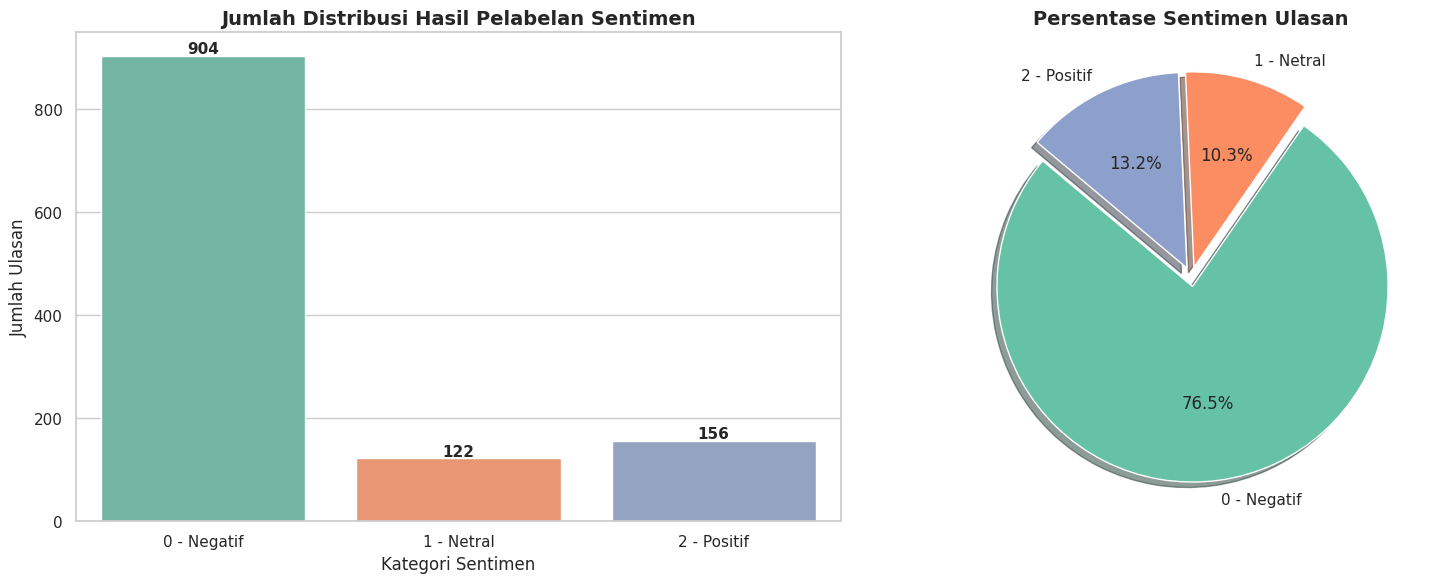

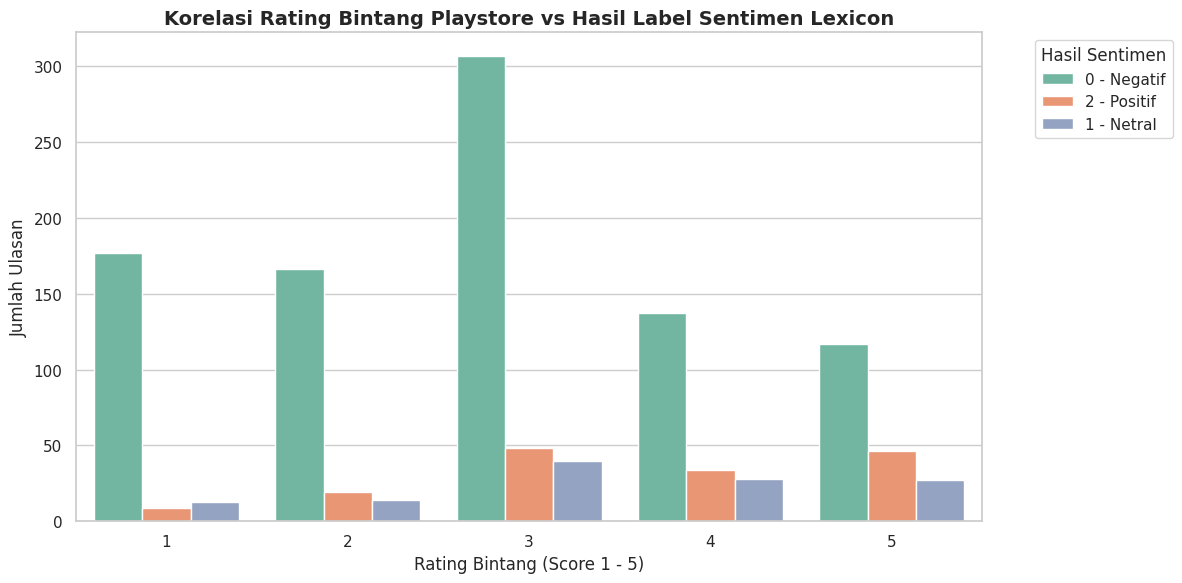


GENERATING WORD CLOUD UNTUK MASING-MASING KATEGORI SENTIMEN...


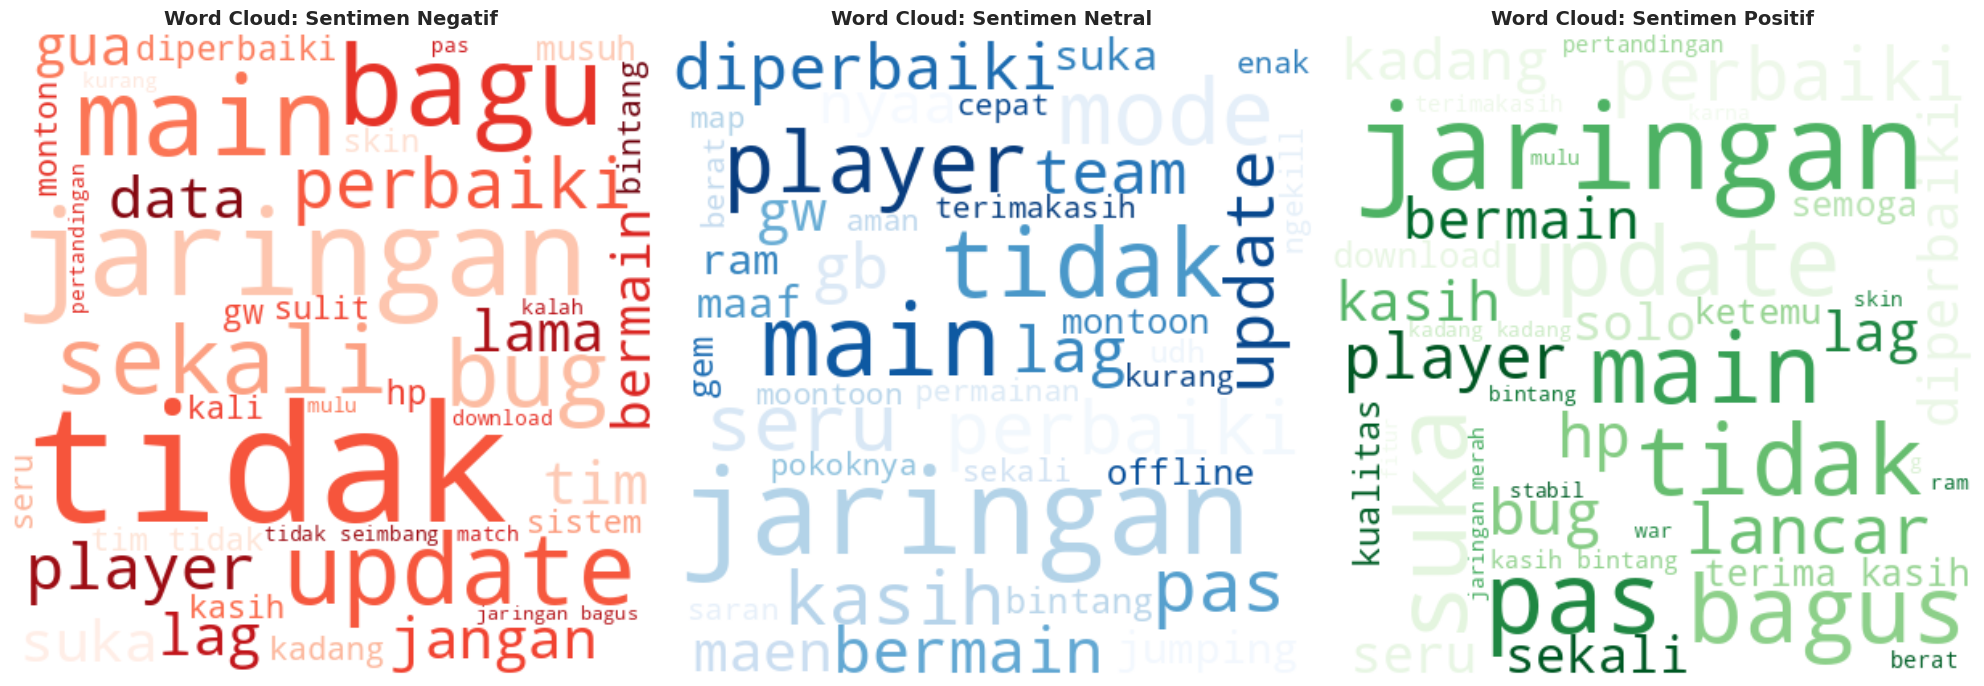


CONTOH 3 ULASAN PALING POPULER (THUMBS UP TERTINGGI) BERDASARKAN KATEGORI SENTIMEN

>>> SENTIMEN: NEGATIF
--------------------------------------------------
Rating: ⭐ 4 | Disetujui: 19953 User
Ulasan: Tolong kembalikan performa Mobile Legends seperti dahulu. Saat sinyal tidak mudah jumping-jumping. Tolong sesuaikan tim ...
----------------------------------------
Rating: ⭐ 2 | Disetujui: 14552 User
Ulasan: Lebih baik pas S29, tidak banyak bug, jaringan stabil, di game tidak berat.. Di season 30 ini banyak perubahan, membuat ...
----------------------------------------
Rating: ⭐ 1 | Disetujui: 13833 User
Ulasan: Sebenarnya game ini bagus, cuman mohon untuk memperbaiki macthmaking nya moonton (terutama pada rekan tim) sehingga bisa...
----------------------------------------

>>> SENTIMEN: NETRAL
--------------------------------------------------
Rating: ⭐ 2 | Disetujui: 8 User
Ulasan: Dulu sebelum update enak enak aja,sekarang sering bug,ngeframe,sinyal langsung hilang.kadang pada posi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from wordcloud import WordCloud

# Menggunakan dataframe hasil pelabelan 'clean_df'
# Mapping label angka ke string untuk kebutuhan visualisasi agar mudah dibaca
sentiment_map = {0: '0 - Negatif', 1: '1 - Netral', 2: '2 - Positif'}
clean_df['sentiment_name'] = clean_df['sentiment_label'].map(sentiment_map)

# Mengatur gaya visualisasi data
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

# ==============================================================================
# 1. VISUALISASI HASIL PELABELAN SENTIMEN (COUNTPLOT & PIE CHART)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# A. Bar Chart Distribusi Sentimen
sns.countplot(x='sentiment_name', data=clean_df, palette='Set2', ax=ax1,
              order=['0 - Negatif', '1 - Netral', '2 - Positif'])
ax1.set_title('Jumlah Distribusi Hasil Pelabelan Sentimen', fontsize=14, fontweight='bold')
ax1.set_xlabel('Kategori Sentimen', fontsize=12)
ax1.set_ylabel('Jumlah Ulasan', fontsize=12)

# Tambahkan label angka di atas batang barchart
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11, fontweight='bold')

# B. Pie Chart Persentase Sentimen
sentiment_counts = clean_df['sentiment_name'].value_counts().reindex(['0 - Negatif', '1 - Netral', '2 - Positif'])
ax2.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('Set2')[:3], explode=(0.05, 0.05, 0.05), shadow=True)
ax2.set_title('Persentase Sentimen Ulasan', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. CROSS-TABULATION: VALIDASI SENTIMEN VS RATING SCORE ASLI
# ==============================================================================
plt.figure(figsize=(12, 6))
# Melakukan cross-check apakah label lexicon sinkron dengan rating bintang dari playstore
sns.countplot(x='score', hue='sentiment_name', data=clean_df, palette='Set2')
plt.title('Korelasi Rating Bintang Playstore vs Hasil Label Sentimen Lexicon', fontsize=14, fontweight='bold')
plt.xlabel('Rating Bintang (Score 1 - 5)', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)
plt.legend(title='Hasil Sentimen', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. WORD CLOUD: KATA KUNCI UTAMA TIAP KELOMPOK SENTIMEN
# ==============================================================================
print("\n" + "="*80)
print("GENERATING WORD CLOUD UNTUK MASING-MASING KATEGORI SENTIMEN...")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
sentiment_labels = [0, 1, 2]
titles = ['Word Cloud: Sentimen Negatif', 'Word Cloud: Sentimen Netral', 'Word Cloud: Sentimen Positif']
colormaps = ['Reds', 'Blues', 'Greens']

for i, label in enumerate(sentiment_labels):
    # Menggabungkan teks clean berdasarkan kelompok sentimennya
    text_data = " ".join(clean_df[clean_df['sentiment_label'] == label]['content_clean'].dropna())

    if len(text_data.strip()) > 0:
        wordcloud = WordCloud(width=400, height=400, background_color='white',
                              colormap=colormaps[i], max_words=40).generate(text_data)
        axes[i].imshow(wordcloud, interpolation='bilinear')
        axes[i].set_title(titles[i], fontsize=14, fontweight='bold')
    else:
        axes[i].text(0.5, 0.5, 'Tidak ada data teks', ha='center', va='center', fontsize=14)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# ==============================================================================
# 4. KORELASI SENTIMEN DENGAN DUKUNGAN (THUMBS UP COUNT)
# ==============================================================================
print("\n" + "="*80)
print("CONTOH 3 ULASAN PALING POPULER (THUMBS UP TERTINGGI) BERDASARKAN KATEGORI SENTIMEN")
print("="*80)

for label in [0, 1, 2]:
    name = 'NEGATIF' if label == 0 else 'NETRAL' if label == 1 else 'POSITIF'
    print(f"\n>>> SENTIMEN: {name}")
    print("-" * 50)

    sub_df = clean_df[clean_df['sentiment_label'] == label].sort_values(by='thumbsUpCount', ascending=False)
    top_reviews = sub_df[['score', 'thumbsUpCount', 'content']].head(3)

    if not top_reviews.empty:
        for idx, row in top_reviews.iterrows():
            print(f"Rating: ⭐ {row['score']} | Disetujui: {row['thumbsUpCount']} User")
            print(f"Ulasan: {row['content'][:120]}...")
            print("-" * 40)
    else:
        print("(Tidak ada ulasan pada kategori ini)")

# **7. Automate Preprocessing**

In [ ]:
import os

# --- 4. DEFINISI ISI KONTEN SKRIP OTOMASI PYTHON (Sinkron & Presisi) ---
automate_script_content = r"""import pandas as pd
import numpy as np
import re
import string
import os
import csv
import requests
from io import StringIO
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def main():
    # --- A. KONFIGURASI PATH BERDASARKAN STRUKTUR WORKSPACE ---
    ROOT_DIR = 'Eksperimen_SML_Ridho-nur-mahmudah'
    INPUT_FILE = os.path.join(ROOT_DIR, 'dataset_raw', 'dataset_mobile_legends.csv')

    OUTPUT_DIR = os.path.join(ROOT_DIR, 'preprocessing', 'dataset')
    OUTPUT_FILE = os.path.join(OUTPUT_DIR, 'dataset_mobile_legends_preprocessed.csv')
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # --- B. LOAD DATA ---
    try:
        if not os.path.exists(INPUT_FILE):
            print(f"[!] Error: File input {INPUT_FILE} tidak ditemukan.")
            return

        df = pd.read_csv(INPUT_FILE)
        print(f"[*] Berhasil memuat data mentah dari: {INPUT_FILE}")
    except Exception as e:
        print(f"[!] Error saat memuat file: {e}")
        return

    # --- C. DROP MISSING VALUES & DUPLICATES ---
    df = df.dropna(subset=['content']).copy()
    df = df.drop_duplicates(subset=['content'])

    # --- D. LOAD KAMUS LEXICON DARI GITHUB ---
    print("[*] Mengunduh kamus lexicon positif & negatif...")
    lexicon_positive = dict()
    res_pos = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
    if res_pos.status_code == 200:
        reader = csv.reader(StringIO(res_pos.text), delimiter=',')
        for row in reader: lexicon_positive[row[0]] = int(row[1])

    lexicon_negative = dict()
    res_neg = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
    if res_neg.status_code == 200:
        reader = csv.reader(StringIO(res_neg.text), delimiter=',')
        for row in reader: lexicon_negative[row[0]] = int(row[1])

    # --- E. SETUP STOPWORDS, STEMMER & SLANG DICTIONARY ---
    factory_sw = StopWordRemoverFactory()
    stop_words = set(factory_sw.get_stop_words())

    # PROTEKSI NEGASI: Keluarkan kata penting dari daftar hapus stopwords
    removable = {'tidak', 'kurang', 'lama', 'lambat', 'sulit', 'masalah', 'salah', 'bukan', 'jangan'}
    for w in removable:
        stop_words.discard(w)

    additional_sw = {
        'yg', 'dg', 'rt', 'dgn', 'ny', 'd', 'kalo', 'amp', 'biar', 'bikin', 'nya',
        'ini', 'itu', 'saya', 'dan', 'di', 'si', 'ya', 'aja', 'ke', 'ka', 'pun',
        'halo', 'admin', 'min', 'mohon', 'woy', 'sih', 'loh', 'user', 'url', 'kak', 'bang',
        'iya', 'yaa', 'gaa', 'woii', 'game', 'gamenya', 'moonton', 'ml', 'hero', 'rank'
    }
    stop_words.update(additional_sw)

    slang_dict = {
        "ga": "tidak", "gak": "tidak", "nggak": "tidak", "gk": "tidak", "tdk": "tidak", "ngak": "tidak",
        "bgt": "sekali", "banget": "sekali", "udah": "sudah", "sdh": "sudah", "dh": "sudah",
        "pake": "pakai", "matchmaking": "matchmaking", "macthmaking": "matchmaking",
        "lag": "lambat", "bug": "bug", "eror": "bug", "error": "bug", "lostrek": "lose streak",
        "jringan": "jaringan", "sinyal": "jaringan", "ping": "jaringan", "jlek": "jelek"
    }

    factory_stemmer = StemmerFactory()
    indonesian_stemmer = factory_stemmer.create_stemmer()

    # --- F. PIPELINE TEXT CLEANING ---
    def text_preprocessing_pipeline(text):
        if not isinstance(text, str):
            return ""

        # Cleaning regex standar teks
        text = re.sub(r'@[A-Za-z0-9_]+', '', text)
        text = re.sub(r'#[A-Za-z0-9_]+', '', text)
        text = re.sub(r'RT[\s]', '', text)
        text = re.sub(r"http\S+", '', text)
        text = re.sub(r'[0-9]+', '', text)
        text = text.replace('\n', ' ')
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'[^\w\s]', '', text).lower().strip()

        # Pemetaan slang dan penyaringan kata (filtering)
        words = text.split()
        fixed_words = []
        for w in words:
            word = slang_dict[w] if w in slang_dict else w
            if word not in stop_words:
                fixed_words.append(word)

        return ' '.join(fixed_words)

    # --- G. FUNGSI PELABELAN LEXICON INDONESIA ---
    def lexicon_labeling(text):
        if not isinstance(text, str) or text.strip() == "":
            return 0, 1
        words = text.split()
        score = 0
        for word in words:
            if word in lexicon_positive: score += abs(lexicon_positive[word])
            if word in lexicon_negative: score -= abs(lexicon_negative[word])

        if score > 0:
            return 2  # Positif
        elif score < 0:
            return 0  # Negatif
        else:
            return 1  # Netral

    # --- H. EKSEKUSI DATA PIPELINE ---
    print("[*] Memulai pembersihan teks, pelabelan, dan stemming (Mohon tunggu)...")
    if 'content' in df.columns:
        # 1. Transformasi Kolom Bersih
        df['content_clean'] = df['content'].apply(text_preprocessing_pipeline)
        df = df[df['content_clean'].str.strip() != ""].copy()

        # 2. Pelabelan Sentimen 3 Kelas (0, 1, 2)
        df['sentiment_label'] = df['content_clean'].apply(lexicon_labeling)

        # 3. Proses Stemming Kata Dasar Sastrawi
        df['content_stemmed'] = df['content_clean'].apply(indonesian_stemmer.stem)
    else:
        print("[!] Error: Kolom 'content' tidak ditemukan dalam dataset.")
        return

    # --- I. SIMPAN HASIL KE TARGET PREPROCESSED ---
    df.to_csv(OUTPUT_FILE, index=False)
    print("-" * 65)
    print(f"[SUCCESS] File hasil otomatisasi disimpan di:\n  => {OUTPUT_FILE}")
    print(f"[*] Total baris data bersih akhir: {len(df)} baris")
    print(f"[*] Sebaran label otomatis: \n{df['sentiment_label'].value_counts()}")
    print("-" * 65)

if __name__ == "__main__":
    main()
"""

# --- 5. MENULIS FILE SCRIPT KE DALAM FOLDER PREPROCESSING ---
file_path_py = os.path.join("Eksperimen_SML_Ridho-nur-mahmudah/preprocessing", 'automate_Ridho-nur-mahmudah.py')

# Memastikan subfolder 'preprocessing' sudah terbentuk agar tidak melempar FileNotFoundError
os.makedirs(os.path.dirname(file_path_py), exist_ok=True)

with open(file_path_py, 'w', encoding='utf-8') as f:
    f.write(automate_script_content)

print(f"[✓] File otomasi berhasil diperbarui di lokasi blueprint: {file_path_py}")
print("[*] Semua komponen data pipeline & workspace kini sinkron 100%!")

[✓] File otomasi berhasil diperbarui di lokasi blueprint: Eksperimen_SML_Ridho-nur-mahmudah/preprocessing/automate_Ridho-nur-mahmudah.py
[*] Semua komponen data pipeline & workspace kini sinkron 100%!


In [ ]:
from google.colab import files

nama_folder_sumber = 'Eksperimen_SML_Ridho-nur-mahmudah'
nama_file_zip = 'Eksperimen_SML_Ridho-nur-mahmudah.zip'

print(f"[*] Sedang mengompres folder '{nama_folder_sumber}' menjadi '{nama_file_zip}'...")

try:
    shutil.make_archive(nama_folder_sumber, 'zip', nama_folder_sumber)
    print("[✓] Proses kompresi berhasil!")

    print("[*] Memulai pengunduhan file ke komputer lokal Anda (Mohon tunggu hingga pop-up unduhan muncul)...")
    files.download(nama_file_zip)

except Exception as e:
    print(f"[!] Terjadi kesalahan saat memproses unduhan: {e}")

[*] Sedang mengompres folder 'Eksperimen_SML_Ridho-nur-mahmudah' menjadi 'Eksperimen_SML_Ridho-nur-mahmudah.zip'...
[✓] Proses kompresi berhasil!
[*] Memulai pengunduhan file ke komputer lokal Anda (Mohon tunggu hingga pop-up unduhan muncul)...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>